# Constrained Tikhonov regularization implemented by (accelerated) forward-backward splitting
We consider the two-dimensional deconvolution problems to find a non-negative function f given data 
$$
    d \sim \mathrm{Pois}(h*f)
$$
with a non-negative convolution kernel $h$, and $\mathrm{Pois}$ denotes the element-wise Poisson distribution.

We explore the use of the semismooth Newton method to implement constrained Tikhonov regularization 
$$
\hat{f} = \mathrm{argmin}_{f\geq 0} \left[\| h*f-d\|^2_{L^2(w)} + \alpha \|f\|^2_{L^2}\right]
$$
with a weight $w = \frac{1}{\sqrt{d+1}}$. The regularization parameter $\alpha$ is chosen by the discrepancy principle.   

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mplib
from regpy.operators import CoordinateMask 
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.proximal_gradient import ForwardBackwardSplitting, FISTA
from regpy.hilbert import L2, HmDomain
from regpy.stoprules import CountIterations, Discrepancy
import logging
from numpy.linalg import norm

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

### plotting routine for comparing reconstructions and originals 

In [17]:
def comparison_plot(grid,truth,reco,title_right='exact',title_left='reconstruction',residual=None):
    plt.rcParams.update({'font.size': 22})
    extent = [grid.axes[0][0],grid.axes[0][-1], grid.axes[1][0], grid.axes[1][-1]]
    maxval = np.max(truth[:]); minval = np.min(truth[:])
    mycmap = mplib.colormaps['hot']
    mycmap.set_over((0,0,1.,1.))  # use blue as access color for large values
    mycmap.set_under((0,1,0,1.))  # use green as access color for small values
    if not (residual is None):
        fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (22,16))
    else:
        fig, (ax1,ax2) = plt.subplots(1,2,figsize = (22,8))
    im1= ax1.imshow(reco.T,extent=extent,origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax1.title.set_text(title_left)
    fig.colorbar(im1,extend='both')
    im2= ax2.imshow(truth.T,extent=extent, origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax2.title.set_text(title_right)
    fig.colorbar(im2,extend='both',orientation='vertical')
    if not (residual is None):
        maxv = np.max(reco[:]-truth[:])
        im3 = ax3.imshow(truth.T-reco.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu_r')
        ax3.title.set_text('reconstruction error')
        fig.colorbar(im3)

        maxv = np.max(residual[:])
        im4 = ax4.imshow(residual.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu_r')
        ax4.title.set_text('data residual')
        fig.colorbar(im4)

### test objects

In [18]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.95)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 200*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


### creating Poisson distributed synthetic data

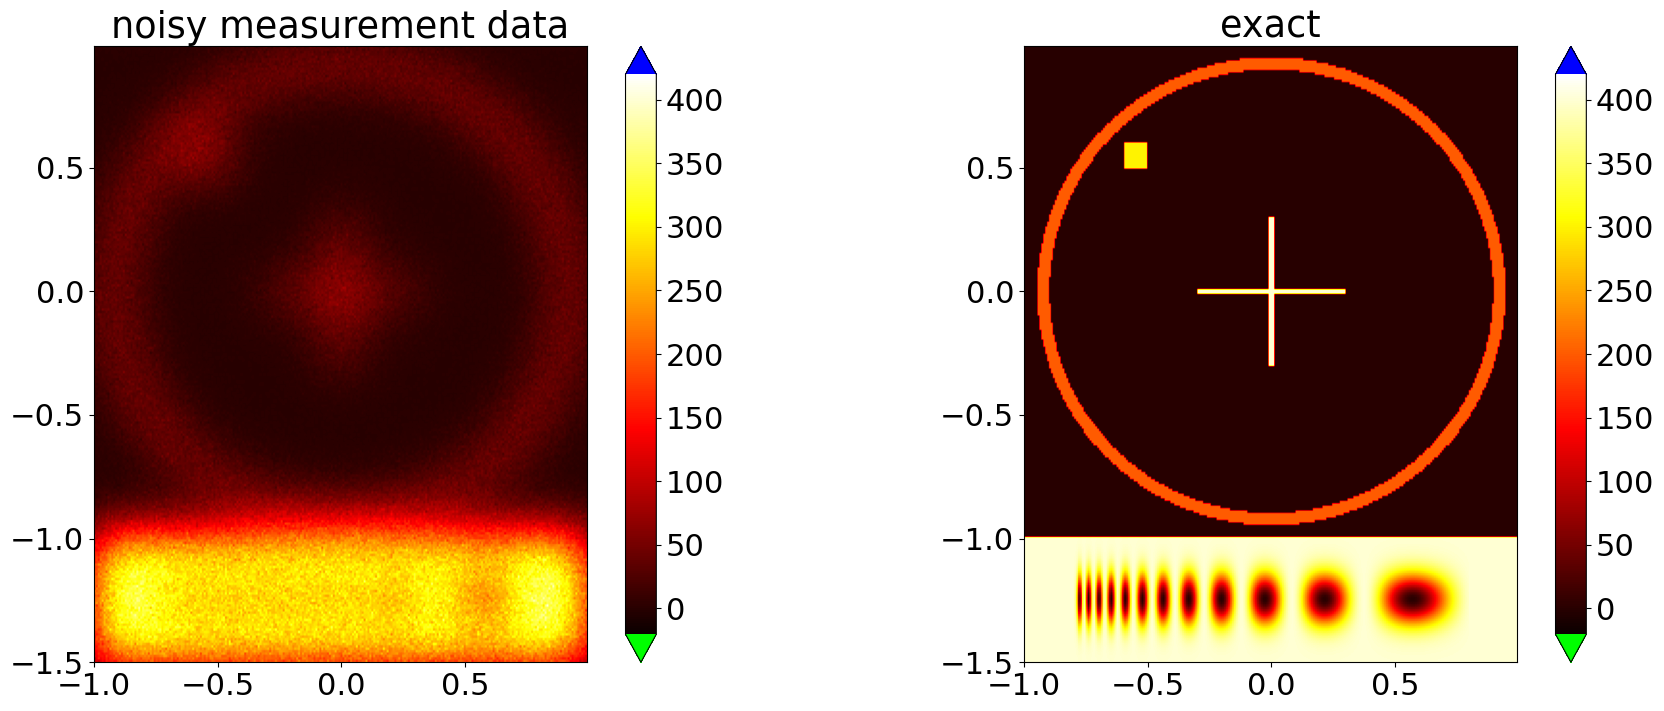

In [19]:
a=0.15
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
"""Simulated exact data."""
data = np.random.poisson(blur)
"""Simulated measured data. The Poisson distribution occurs if photon count detectors are used."""
comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

### Reconstruction by Forward-Backward Splitting 
We split the Tikhonov functional into the quadratic data fidelity term and a penalty term, which also includes the nonnegativity constraint. Then forward-backward splitting is applied to this splitting of the Tikhonov functional. 

2024-05-29 21:53:46,023 INFO CountIterations      :: iteration = 1 / 300
2024-05-29 21:53:46,048 INFO CountIterations      :: iteration = 2 / 300
2024-05-29 21:53:46,073 INFO CountIterations      :: iteration = 3 / 300
2024-05-29 21:53:46,103 INFO CountIterations      :: iteration = 4 / 300
2024-05-29 21:53:46,131 INFO CountIterations      :: iteration = 5 / 300
2024-05-29 21:53:46,157 INFO CountIterations      :: iteration = 6 / 300
2024-05-29 21:53:46,211 INFO CountIterations      :: iteration = 7 / 300
2024-05-29 21:53:46,233 INFO CountIterations      :: iteration = 8 / 300
2024-05-29 21:53:46,262 INFO CountIterations      :: iteration = 9 / 300
2024-05-29 21:53:46,287 INFO CountIterations      :: iteration = 10 / 300
2024-05-29 21:53:46,307 INFO CountIterations      :: iteration = 11 / 300
2024-05-29 21:53:46,330 INFO CountIterations      :: iteration = 12 / 300
2024-05-29 21:53:46,353 INFO CountIterations      :: iteration = 13 / 300
2024-05-29 21:53:46,381 INFO CountIterations   

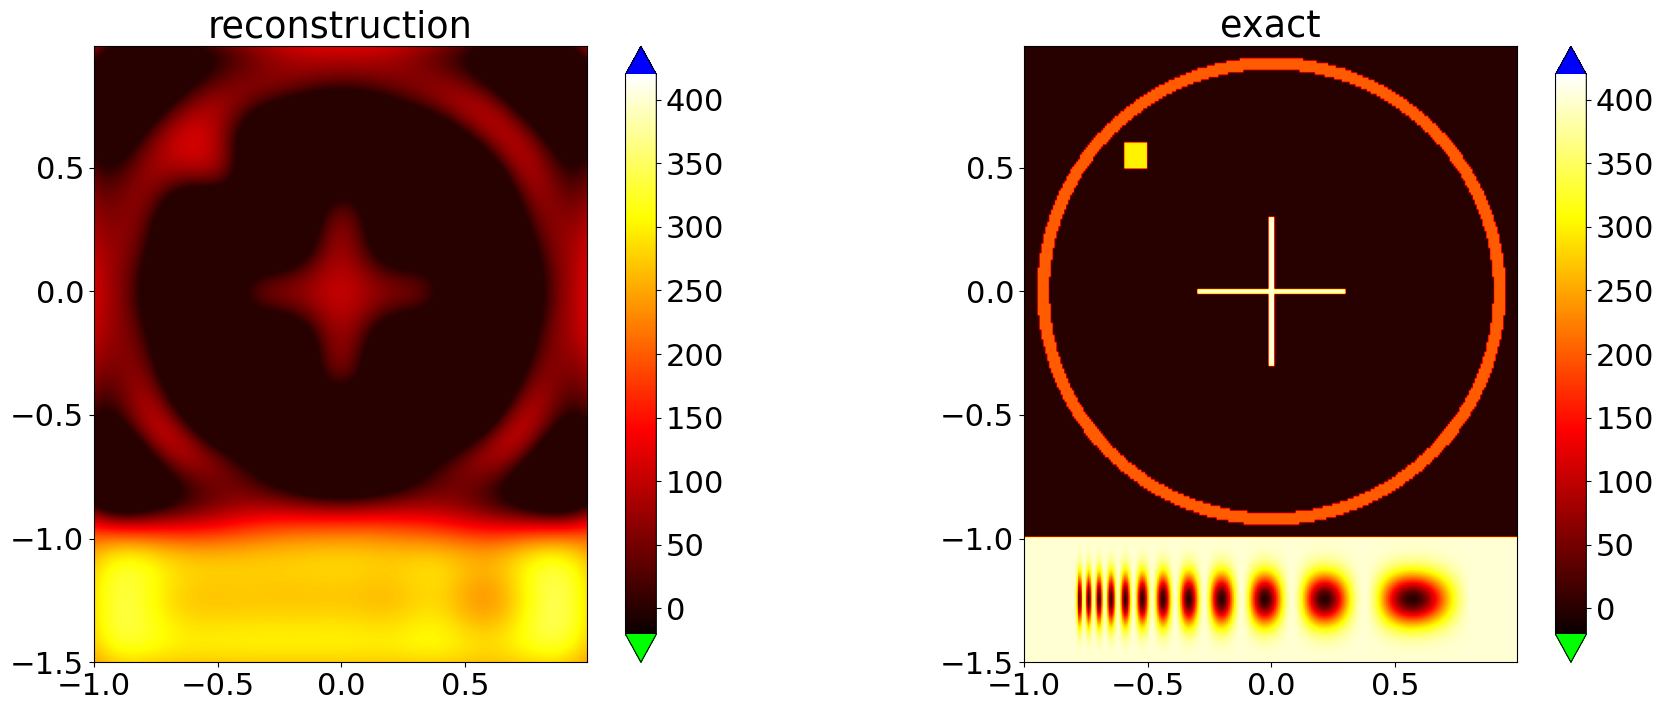

In [28]:
from regpy.functionals import QuadraticBilateralConstraints
weighted_data_space = L2(grid, weights = 1./(1.+data))
pen = QuadraticBilateralConstraints(grid,grid.zeros(), 400*grid.ones(),grid.zeros())
alpha = 1e-3
setting = TikhonovRegularizationSetting(op=conv, penalty=pen, data_fid = weighted_data_space,data_fid_shift=data,regpar=alpha)
setting.penalty
#solver = ForwardBackwardSplitting(setting)
solver = FISTA(setting)
stoprule=CountIterations(100)
x,y = solver.run(stoprule)
comparison_plot(grid,exact_sol,x)


In [29]:
solver.tau

2.182309014311457

### Reconstruction with one sided constraints

2024-05-29 21:50:41,917 INFO CountIterations      :: iteration = 1 / 100
2024-05-29 21:50:41,941 INFO CountIterations      :: iteration = 2 / 100
2024-05-29 21:50:41,964 INFO CountIterations      :: iteration = 3 / 100
2024-05-29 21:50:41,983 INFO CountIterations      :: iteration = 4 / 100
2024-05-29 21:50:42,002 INFO CountIterations      :: iteration = 5 / 100
2024-05-29 21:50:42,016 INFO CountIterations      :: iteration = 6 / 100
2024-05-29 21:50:42,036 INFO CountIterations      :: iteration = 7 / 100
2024-05-29 21:50:42,056 INFO CountIterations      :: iteration = 8 / 100
2024-05-29 21:50:42,080 INFO CountIterations      :: iteration = 9 / 100
2024-05-29 21:50:42,099 INFO CountIterations      :: iteration = 10 / 100
2024-05-29 21:50:42,118 INFO CountIterations      :: iteration = 11 / 100
2024-05-29 21:50:42,135 INFO CountIterations      :: iteration = 12 / 100
2024-05-29 21:50:42,155 INFO CountIterations      :: iteration = 13 / 100
2024-05-29 21:50:42,175 INFO CountIterations   

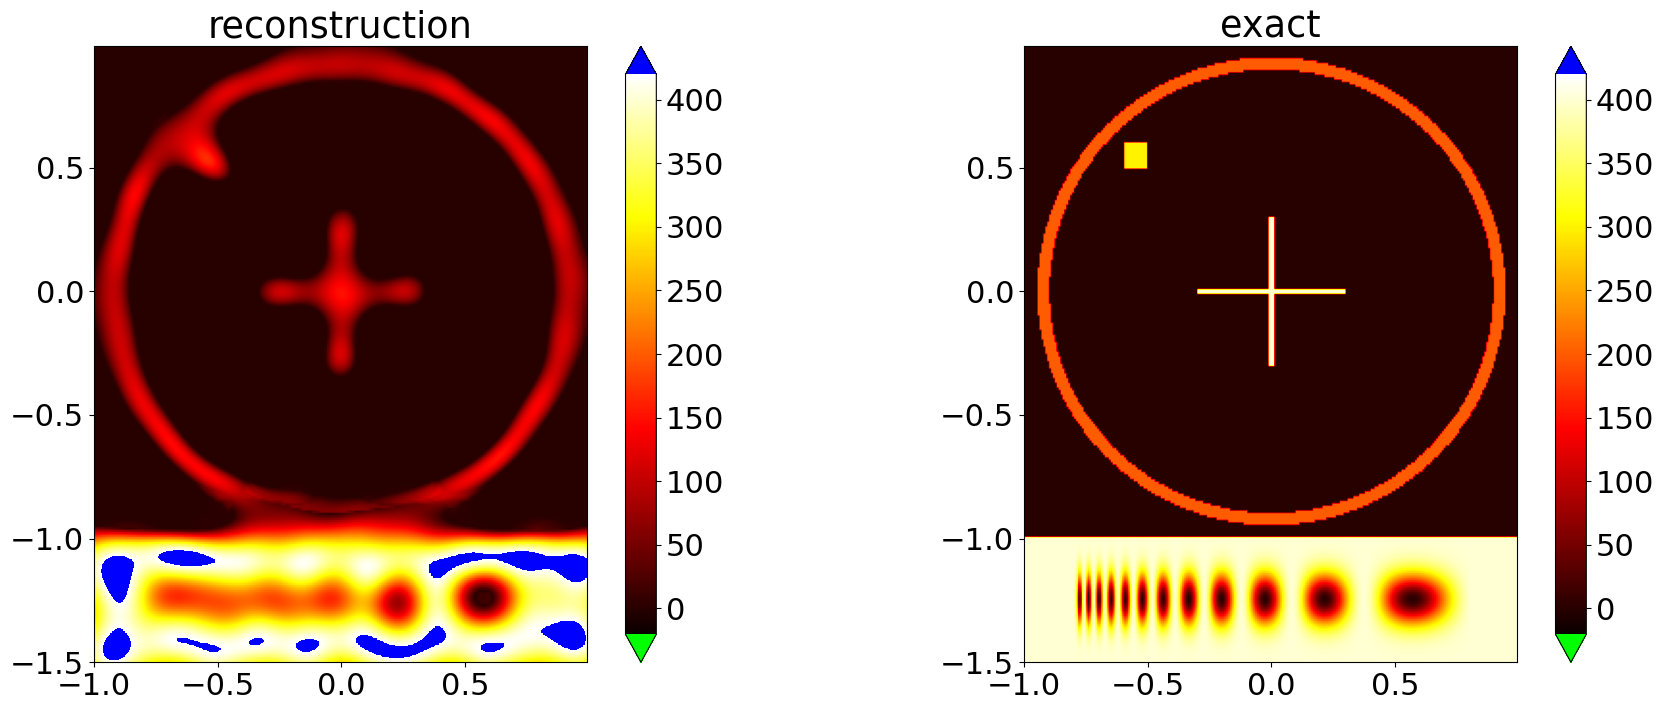

In [22]:
from regpy.functionals import QuadraticLowerBound
weighted_data_space = L2(grid, weights = 1./(1.+data))
alpha = 1e-3
pen = QuadraticLowerBound(grid,grid.zeros(), 50*grid.ones(),alpha)
setting = TikhonovRegularizationSetting(op=conv, penalty=pen, data_fid = L2,data_fid_shift=data,regpar=alpha)
#solver = ForwardBackwardSplitting(setting,grid.zeros())
solver = FISTA(setting)
stoprule=CountIterations(100)
x,y = solver.run(stoprule)
comparison_plot(grid,exact_sol,x)

### Comparison: reconstruction without constraints but with restriction after solution

2024-05-29 21:50:45,542 INFO CountIterations      :: iteration = 1 / 100
2024-05-29 21:50:45,556 INFO CountIterations      :: iteration = 2 / 100
2024-05-29 21:50:45,575 INFO CountIterations      :: iteration = 3 / 100
2024-05-29 21:50:45,591 INFO CountIterations      :: iteration = 4 / 100
2024-05-29 21:50:45,608 INFO CountIterations      :: iteration = 5 / 100
2024-05-29 21:50:45,622 INFO CountIterations      :: iteration = 6 / 100
2024-05-29 21:50:45,638 INFO CountIterations      :: iteration = 7 / 100
2024-05-29 21:50:45,650 INFO CountIterations      :: iteration = 8 / 100
2024-05-29 21:50:45,665 INFO CountIterations      :: iteration = 9 / 100
2024-05-29 21:50:45,679 INFO CountIterations      :: iteration = 10 / 100
2024-05-29 21:50:45,697 INFO CountIterations      :: iteration = 11 / 100
2024-05-29 21:50:45,711 INFO CountIterations      :: iteration = 12 / 100
2024-05-29 21:50:45,730 INFO CountIterations      :: iteration = 13 / 100
2024-05-29 21:50:45,747 INFO CountIterations   

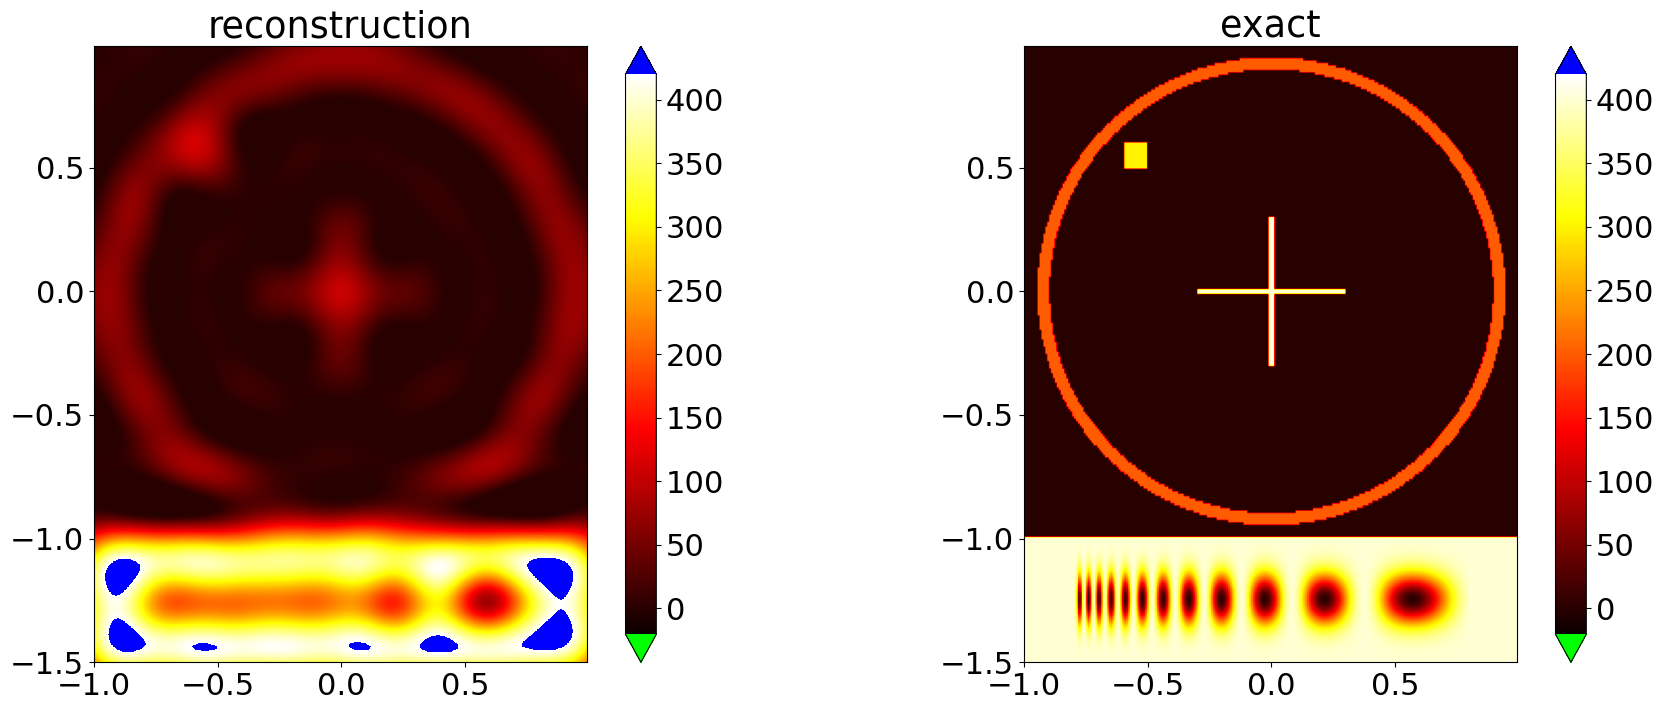

In [23]:
weighted_data_space = L2(grid, weights = 1./(1.+data))
alpha = 1e-3
pen = L2
setting = TikhonovRegularizationSetting(op=conv, penalty=pen, data_fid = L2,data_fid_shift=data,regpar=alpha)
setting.penalty
solver = ForwardBackwardSplitting(setting,grid.zeros())
#solver = FISTA(setting)

stoprule=CountIterations(100)
x,y = solver.run(stoprule)
x=np.maximum(x,0)
comparison_plot(grid,exact_sol,x)